In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
#Loading the video
cap = cv2.VideoCapture('Robots.mp4')         

Method 1 : Sparse Optical Flow 
480 frames

In [ ]:
#Reading each image 
count = 0 #Counter for the number of frames
track_count = 0
ret1, frame1 = cap.read()
while ret1:
    b1,g1,r1 = cv2.split(frame1) # Changing the order from bgr to rgb so that matplotlib can show it
    img1 = cv2.merge([r1,g1,b1])
    #plt.imshow(img1)
    #Convert the image in grayscale
    gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    #Detect the feature using Shi-Tomasi 
    feat1 = cv2.goodFeaturesToTrack(gray1, maxCorners = 150, qualityLevel = 0.02,
                minDistance = 20) 
    #Proceed the same with the next frame
    while track_count<10:
        ret2,frame2 = cap.read()
    track_count = 0
    if ret2:
        b2,g2,r2 = cv2.split(frame2) # Changing the order from bgr to rgb so that matplotlib can show it
        img2 = cv2.merge([r2,g2,b2])
        #plt.imshow(img2)
        #Convert the image in grayscale
        gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
        #Track the features in the next frame
        feat2, status, error = cv2.calcOpticalFlowPyrLK(gray1, gray2, feat1, None)
    
        #Test the tracking by displaying the features movement on the latest frame
        for i in range(len(feat1)):
            f10=int(feat1[i][0][0])
            f11=int(feat1[i][0][1])
            f20=int(feat2[i][0][0])
            f21=int(feat2[i][0][1])
            #dist = ((f10 -f20)**2 +(f11-f21)**2)**0.5
            #We put a threshold on how much of distance do we consider a displacement
            #if dist >10:
            cv2.line(img2, (f10,f11), (f20, f21), (0, 255, 0), 2)
            cv2.circle(img2, (f10, f11), 5, (0, 255, 0), -1)
        #Store the frame 
        cv2.imwrite("frame%d.jpg" % count, img2)
        count = count+1
        ret1 = ret2
        frame1 = frame2
        #plt.figure(figsize=(15,15))
        #plt.imshow(img2)
        print(count)
cap.release()


In [13]:
#Display all images 
count = 480
for i in range(count+1):
    # Display the frame using imshow
    img = cv2.imread("frame%d.jpg" % i)
    #b,g,r = cv2.split(img)
    #img = cv2.merge([r,g,b])
    #plt.imshow(img)
    cv2.imshow("frame%d.jpg" % i, img)
    cv2.waitKey(500)  
cv2.destroyAllWindows()  # Close the window

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77


KeyboardInterrupt: 

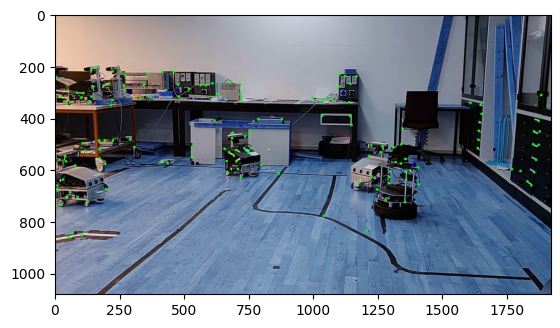

In [4]:
count = 50
img = cv2.imread("frame%d.jpg" % count)
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
plt.imshow(img)